In [157]:
import mlflow
import mlflow.sklearn
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
import numpy as np
import os
import pickle
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error
import itertools  # For grid search
import warnings

warnings.filterwarnings('ignore')

from prophet import Prophet
from xgboost import XGBRegressor



In [156]:

# Tracking URL
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
mlflow.set_tracking_uri(f"file:///users/jmofl/pycharmProjects/mlrun")
Favorita_project2026 = "favorita_sales_forecasting"
mlflow.set_experiment(Favorita_project2026)

<Experiment: artifact_location='file:C:/users/jmofl/pycharmProjects/mlrun/797940398248105337', creation_time=1772187240975, experiment_id='797940398248105337', last_update_time=1772187240975, lifecycle_stage='active', name='favorita_sales_forecasting', tags={}, workspace='default'>

In [158]:
# 2. Load and Prepare Data
data_folder = r'C:\Users\jmofl\PycharmProjects\TimeSeriesProject_Feb_2026\data'
df = pd.read_csv(os.path.join(data_folder, 'cleaned_timeseries.csv'), parse_dates=['date'])
holidays = pd.read_csv(os.path.join(data_folder, 'holidays.csv'), parse_dates=['date'])

In [114]:

# Process Holidays for exog (one-hot)
holiday_dummies = pd.get_dummies(holidays[['date', 'locale']], columns=['locale'], dtype=int)
holiday_dummies = holiday_dummies.groupby('date').max().reset_index()

# Merge and Set Index
df = pd.merge(df, holiday_dummies, on='date', how='left').fillna(0)
df = df.set_index('date').sort_index()
df = df.asfreq('D', method='ffill')  # Handle gaps
df.index.freq = 'D'

target = 'unit_sales'
exog_cols = [c for c in df.columns if c.startswith('locale_')]

In [166]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Your dataframe already has date as index
print("Original shape:", df.shape)
print("Date range:", df.index.min(), "to", df.index.max())

# Ensure index is datetime (it should be, but just in case)
df.index = pd.to_datetime(df.index)

# Split by date
train = df.loc[df.index < '2014-01-01']
test = df.loc[df.index >= '2014-01-01']


# Further split train for validation (time-based, no shuffle)
train_data, val_data = train_test_split(train, test_size=0.2, shuffle=False)


Original shape: (454, 1)
Date range: 2013-01-02 00:00:00 to 2014-03-31 00:00:00


In [167]:
# 3. Function to Evaluate Model (for tuning)
def evaluate_model(model, train_y, val_y, train_exog=None, val_exog=None):
    model_fit = model.fit(disp=False)
    forecast = model_fit.get_forecast(steps=len(val_y), exog=val_exog).predicted_mean
    return mean_absolute_error(val_y, forecast)

In [168]:
# Run this FIRST - save the fitted model to a variable
sarimax_model = SARIMAX(train['unit_sales'],
                        order=(3, 1, 3),
                        seasonal_order=(1, 1, 1, 7)).fit(maxiter=1000, disp=False)

# Verify it worked
print(f"AIC: {sarimax_model.aic}")
print(f"BIC: {sarimax_model.bic}")

AIC: 4416.459391260012
BIC: 4451.33376783768


In [169]:
# 4. SARIMAX Tuning (Grid Search)
def tune_sarimax(train_y, train_exog, val_y, val_exog):
    p = d = q = range(0, 3)
    pdq = list(itertools.product(p, d, q))
    seasonal_pdq = [(x[0], x[1], x[2], 7) for x in pdq]

    best_mae = float('inf')
    best_params = None

    for param in pdq:
        for s_param in seasonal_pdq:
            try:
                mod = SARIMAX(train_y, exog=train_exog, order=param, seasonal_order=s_param,
                              enforce_stationarity=False, enforce_invertibility=False)
                mae = evaluate_model(mod, train_y, val_y, train_exog, val_exog)
                if mae < best_mae:
                    best_mae = mae
                    best_params = (param, s_param)
            except:
                continue
    print(f"Best SARIMAX Params: {best_params} (MAE: {best_mae:.2f})")
    return best_params

In [170]:
import pickle

# save SARIMAX in MLFLOW
with mlflow.start_run(run_name="SARIMAX"):
    # Log parameters
    mlflow.log_param("order", str((3, 1, 3)))
    mlflow.log_param("seasonal_order", str((1, 1, 1, 7)))

    # Log metrics - use the variable from Step 1
    mlflow.log_metric("aic", sarimax_model.aic)
    mlflow.log_metric("bic", sarimax_model.bic)

    # Save model
    with open("sarimax_model.pkl", "wb") as f:
        pickle.dump(sarimax_model, f)
    mlflow.log_artifact("sarimax_model.pkl")

    print(f"Run ID: {mlflow.active_run().info.run_id}")

Run ID: 65dbfa56ecb745dcb10d578f2e9e1d60


In [171]:
# 5. Prophet Tuning (Grid Search; assumes Prophet installed)
def tune_prophet(train_df, val_df):
    param_grid = {
        'changepoint_prior_scale': [0.001, 0.01, 0.1],
        'seasonality_prior_scale': [0.01, 0.1, 1.0]
    }
    grid = list(itertools.product(*param_grid.values()))

    best_mae = float('inf')
    best_params = None

    for params in grid:
        param_dict = dict(zip(param_grid.keys(), params))
        m = Prophet(**param_dict, daily_seasonality=False)
        m.fit(train_df.rename(columns={'unit_sales': 'y', 'date': 'ds'}))
        future = m.make_future_dataframe(periods=len(val_df))
        forecast = m.predict(future)['yhat'][-len(val_df):]
        mae = mean_absolute_error(val_df['unit_sales'], forecast)
        if mae < best_mae:
            best_mae = mae
            best_params = param_dict
    print(f"Best Prophet Params: {best_params} (MAE: {best_mae:.2f})")
    return best_params

In [172]:
import pickle
import mlflow
from prophet import Prophet
from sklearn.metrics import mean_absolute_error

# Create date column if you don't have one
# Assuming your index is the date or you have a date column somewhere
# If not, you'll need to create a 'ds' column from your index

# For Prophet, we need to rename your columns
train_prophet = train[['unit_sales']].copy()
test_prophet = test[['unit_sales']].copy()

# Add a date column (ds) - using index as date if it's datetime
train_prophet['ds'] = train_prophet.index  # or use your actual date column
test_prophet['ds'] = test_prophet.index

# Rename unit_sales to y for Prophet
train_prophet = train_prophet.rename(columns={'unit_sales': 'y'})
test_prophet = test_prophet.rename(columns={'unit_sales': 'y'})

# Train Prophet model
prophet_model = Prophet()
prophet_model.fit(train_prophet[['ds', 'y']])

# Log to MLflow
with mlflow.start_run(run_name="Prophet"):
    mlflow.log_param("seasonality_mode", "additive")

    forecast = prophet_model.predict(test_prophet[['ds']])
    mae = mean_absolute_error(test_prophet['y'], forecast['yhat'])
    mlflow.log_metric("mae", mae)

    with open("prophet_model.pkl", "wb") as f:
        pickle.dump(prophet_model, f)
    mlflow.log_artifact("prophet_model.pkl")

    print(f"Run ID: {mlflow.active_run().info.run_id}")

DEBUG:cmdstanpy:cmd: where.exe tbb.dll
cwd: None
DEBUG:cmdstanpy:TBB already found in load path
INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: C:\Users\jmofl\AppData\Local\Temp\tmpcvvmnbam\1r7ncva8.json
DEBUG:cmdstanpy:input tempfile: C:\Users\jmofl\AppData\Local\Temp\tmpcvvmnbam\deg6qe3a.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['C:\\Users\\jmofl\\PycharmProjects\\TimeSeriesProject_Feb_2026\\.venv\\Lib\\site-packages\\prophet\\stan_model\\prophet_model.bin', 'random', 'seed=71318', 'data', 'file=C:\\Users\\jmofl\\AppData\\Local\\Temp\\tmpcvvmnbam\\1r7ncva8.json', 'init=C:\\Users\\jmofl\\AppData\\Local\\Temp\\tmpcvvmnbam\\deg6qe3a.json', 'output', 'file=C:\\Users\\jmofl\\AppData\\Local\\Temp\\tmpcvvmnbam\\prophet_modelqkjj3j59\\prophet_

Run ID: 44cec46965864c55a9a57ee63b0d8060


In [173]:
# 6. XGBoost Tuning
def tune_xgboost(train_X, train_y, val_X, val_y):
    param_grid = {
        'n_estimators': [100, 300],
        'learning_rate': [0.01, 0.1],
        'max_depth': [3, 5]
    }
    grid = list(itertools.product(*param_grid.values()))

    best_mae = float('inf')
    best_params = None

    for params in grid:
        param_dict = dict(zip(param_grid.keys(), params))
        model = XGBRegressor(**param_dict)
        model.fit(train_X, train_y)
        preds = model.predict(val_X)
        mae = mean_absolute_error(val_y, preds)
        if mae < best_mae:
            best_mae = mae
            best_params = param_dict
    print(f"Best XGBoost Params: {best_params} (MAE: {best_mae:.2f})")
    return best_params


In [174]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error

# Prepare your data (adjust column names as needed)
X_train = train.drop('unit_sales', axis=1)  # Features
y_train = train['unit_sales']               # Target
X_test = test.drop('unit_sales', axis=1)
y_test = test['unit_sales']

# Train XGBoost model
xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1)
xgb_model.fit(X_train, y_train)

# Make predictions
xgb_predictions = xgb_model.predict(X_test)

IndexError: list index out of range

In [127]:
# If your model is already trained as 'xgb_model'
xgb_predictions = xgb_model.predict(X_test)  # Add this line

# Then your MLflow code
with mlflow.start_run(run_name="xgboost"):
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("learning_rate", 0.1)
    mlflow.log_metric("mae", mean_absolute_error(test['unit_sales'], xgb_predictions))

    with open("xgb_model.pkl", "wb") as f:
        pickle.dump(xgb_model, f)
    mlflow.log_artifact("xgb_model.pkl")

In [128]:

# Prepare features for XGBoost (e.g., lags, dayofweek)
def add_features(df):
    df['lag7'] = df[target].shift(7)
    df['dayofweek'] = df.index.dayofweek
    return df.dropna()


train = add_features(train)
test = add_features(test)
train_data, val_data = train_test_split(train, test_size=0.2, shuffle=False)
train_X, val_X = train_data[exog_cols + ['lag7', 'dayofweek']], val_data[exog_cols + ['lag7', 'dayofweek']]
train_y, val_y = train_data[target], val_data[target]

In [129]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error
import itertools

def tune_xgboost(X_train, y_train, X_val, y_val):
    """
    Simple XGBoost hyperparameter tuning
    """
    # Define parameter grid
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 6, 9],
        'learning_rate': [0.01, 0.1, 0.3]
    }

    best_score = float('inf')
    best_params = None
    best_model = None

    # Grid search
    for n_est in param_grid['n_estimators']:
        for depth in param_grid['max_depth']:
            for lr in param_grid['learning_rate']:
                # Train model
                model = xgb.XGBRegressor(
                    n_estimators=n_est,
                    max_depth=depth,
                    learning_rate=lr,
                    random_state=42
                )
                model.fit(X_train, y_train)

                # Predict and evaluate
                preds = model.predict(X_val)
                mae = mean_absolute_error(y_val, preds)

                # Update best
                if mae < best_score:
                    best_score = mae
                    best_params = {
                        'n_estimators': n_est,
                        'max_depth': depth,
                        'learning_rate': lr
                    }
                    best_model = model

                print(f"Params: n_est={n_est}, depth={depth}, lr={lr} - MAE: {mae:.2f}")

    print(f"\nBest XGBoost Params: {best_params} (MAE: {best_score:.2f})")
    return best_params, best_model, best_score

In [130]:

# Run Tuning
sarimax_params = tune_sarimax(train_data[target], train_data[exog_cols], val_data[target], val_data[exog_cols])
prophet_params = tune_prophet(train_data.reset_index(), val_data.reset_index())
xgboost_params = tune_xgboost(train_X, train_y, val_X, val_y)

DEBUG:cmdstanpy:cmd: where.exe tbb.dll
cwd: None
DEBUG:cmdstanpy:TBB already found in load path
INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: C:\Users\jmofl\AppData\Local\Temp\tmpcvvmnbam\t0hxyvwg.json
DEBUG:cmdstanpy:input tempfile: C:\Users\jmofl\AppData\Local\Temp\tmpcvvmnbam\nmygnmbm.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['C:\\Users\\jmofl\\PycharmProjects\\TimeSeriesProject_Feb_2026\\.venv\\Lib\\site-packages\\prophet\\stan_model\\prophet_model.bin', 'random', 'seed=78746', 'data', 'file=C:\\Users\\jmofl\\AppData\\Local\\Temp\\tmpcvvmnbam\\t0hxyvwg.json', 'init=C:\\Users\\jmofl\\AppData\\Local\\Temp\\tmpcvvmnbam\\nmygnmbm.json', 'output', 'file=C:\\Users\\jmofl\\AppData\\Local\\Temp\\tmpcvvmnbam\\prophet_modelvxo1maq3\\prophet_model-20260303195728.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
19:57:28 - cmdstanpy 

Best SARIMAX Params: ((0, 2, 2), (0, 1, 2, 7)) (MAE: 77.74)


19:57:29 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
19:57:29 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
DEBUG:cmdstanpy:input tempfile: C:\Users\jmofl\AppData\Local\Temp\tmpcvvmnbam\vmm_eiuq.json
DEBUG:cmdstanpy:input tempfile: C:\Users\jmofl\AppData\Local\Temp\tmpcvvmnbam\q4ttzoi0.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['C:\\Users\\jmofl\\PycharmProjects\\TimeSeriesProject_Feb_2026\\.venv\\Lib\\site-packages\\prophet\\stan_model\\prophet_model.bin', 'random', 'seed=57872', 'data', 'file=C:\\Users\\jmofl\\AppData\\Local\\Temp\\tmpcvvmnbam\\vmm_eiuq.json', 'init=C:\\Users\\jmofl\\AppData\\Local\\Temp\\tmpcvvmnbam\\q4ttzoi0.json', 'output', 'file=C:\\Users\\jmofl\\AppData\\Local\\Temp\\tmpcvvmnbam\\prophet_modelqfu8he0m\\prophet_model-20260303195729.csv', 'method=optimize', 'algorit

Best Prophet Params: {'changepoint_prior_scale': 0.001, 'seasonality_prior_scale': 0.1} (MAE: 80.38)
Params: n_est=50, depth=3, lr=0.01 - MAE: 98.12
Params: n_est=50, depth=3, lr=0.1 - MAE: 80.29
Params: n_est=50, depth=3, lr=0.3 - MAE: 79.14
Params: n_est=50, depth=6, lr=0.01 - MAE: 98.74
Params: n_est=50, depth=6, lr=0.1 - MAE: 85.56
Params: n_est=50, depth=6, lr=0.3 - MAE: 94.63
Params: n_est=50, depth=9, lr=0.01 - MAE: 100.86
Params: n_est=50, depth=9, lr=0.1 - MAE: 97.39
Params: n_est=50, depth=9, lr=0.3 - MAE: 103.34
Params: n_est=100, depth=3, lr=0.01 - MAE: 89.04
Params: n_est=100, depth=3, lr=0.1 - MAE: 78.36
Params: n_est=100, depth=3, lr=0.3 - MAE: 84.00
Params: n_est=100, depth=6, lr=0.01 - MAE: 90.48
Params: n_est=100, depth=6, lr=0.1 - MAE: 91.75
Params: n_est=100, depth=6, lr=0.3 - MAE: 98.87
Params: n_est=100, depth=9, lr=0.01 - MAE: 93.63
Params: n_est=100, depth=9, lr=0.1 - MAE: 100.60
Params: n_est=100, depth=9, lr=0.3 - MAE: 106.50
Params: n_est=200, depth=3, lr=0.0

In [135]:
# MLFlow save XGBoost
with mlflow.start_run(run_name="XGBoost"):
    mlflow.log_param("model_type", "xgboost")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 6)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("rmse", rmse)
    mlflow.sklearn.log_model(xgb_model, name="model")
    print(f"XGBoost - MAE: {mae:.4f}")

2026/03/03 20:09:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGBoost - MAE: 140.6140


In [141]:

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# MLFlow logging
with mlflow.start_run(run_name="LinearReg"):
    mlflow.log_param("model_type", "linear_regression")
    mlflow.log_param("fit_intercept", True)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("r2", r2)
    mlflow.sklearn.log_model(lr_model, name="model")
    print(f"Linear Regression - MSE: {mse:.4f}, R2: {r2:.4f}")

2026/03/03 20:14:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Linear Regression - MSE: 33951.4108, R2: -0.0085


In [142]:
# MLFlow save Prophet
with mlflow.start_run(run_name="Prophet"):
    mlflow.log_param("model_type", "prophet")
    mlflow.log_param("seasonality_mode", "additive")
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("rmse", rmse)
    # Note: Prophet models need pickle, not sklearn.log_model
    with open("prophet_model.pkl", "wb") as f:
        pickle.dump(prophet_model, f)
    mlflow.log_artifact("prophet_model.pkl")
    print(f"Prophet - MAE: {mae:.4f}")

Prophet - MAE: 140.6140


In [143]:
# MLFlow save SARIMAX
with mlflow.start_run(run_name="SARIMAX"):
    mlflow.log_param("model_type", "sarimax")
    mlflow.log_param("order", str((3,1,3)))
    mlflow.log_param("seasonal_order", str((1,1,1,7)))
    mlflow.log_metric("aic", sarimax_model.aic)
    mlflow.log_metric("bic", sarimax_model.bic)
    with open("sarimax_model.pkl", "wb") as f:
        pickle.dump(sarimax_model, f)
    mlflow.log_artifact("sarimax_model.pkl")
    print(f"SARIMAX - AIC: {sarimax_model.aic:.2f}")

SARIMAX - AIC: 4416.46


In [146]:
# FIRST - Define your variables from your hyperopt results
# Assuming you have xgboost_params from your tuning
if 'xgboost_params' in dir():
    best_params = xgboost_params[0]  # Element [0] is params dict
    best_mae = xgboost_params[2]      # Element [2] is MAE score
    best_model = xgboost_params[1]    # Element [1] is model


else:
    # Or define them manually if you know the values
    best_params = {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1}
    best_mae = 86.32
    best_model = xgb_model  # Your model variable
# MLflow save
with mlflow.start_run(run_name="Hyperopt_Best"):
    mlflow.log_params(best_params)      # Now defined
    mlflow.log_metric("best_mae", best_mae)  # Now defined
    mlflow.sklearn.log_model(best_model, name="best_model")  # Now defined
    print(f"Best Model - MAE: {best_mae:.4f}")

2026/03/03 20:18:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Best Model - MAE: 78.3590


In [149]:
print(train.info())


<class 'pandas.DataFrame'>
DatetimeIndex: 357 entries, 2013-01-09 to 2013-12-31
Freq: D
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   unit_sales       357 non-null    float64
 1   locale_Local     357 non-null    float64
 2   locale_National  357 non-null    float64
 3   locale_Regional  357 non-null    float64
 4   lag7             357 non-null    float64
 5   dayofweek        357 non-null    int32  
dtypes: float64(5), int32(1)
memory usage: 18.1 KB
None


In [150]:
from statsmodels.tsa.arima.model import ARIMA
import mlflow
import pickle

# Use the correct column name: 'unit_sales'
arima_model = ARIMA(train['unit_sales'], order=(2,1,2))
arima_model = arima_model.fit()

# Log to MLflow
with mlflow.start_run(run_name="ARIMA"):
    mlflow.log_param("model_type", "arima")
    mlflow.log_param("order", str((2,1,2)))
    mlflow.log_metric("aic", arima_model.aic)
    mlflow.log_metric("bic", arima_model.bic)

    with open("arima_model.pkl", "wb") as f:
        pickle.dump(arima_model, f)
    mlflow.log_artifact("arima_model.pkl")

    print(f"ARIMA - AIC: {arima_model.aic:.2f}, BIC: {arima_model.bic:.2f}")

ARIMA - AIC: 4588.22, BIC: 4607.60


In [152]:
import mlflow
import pickle
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Step 1: Train the model
print("Training SARIMA model...")
sarima_model = SARIMAX(train['unit_sales'],
                       order=(1,1,1),
                       seasonal_order=(1,1,1,12))
sarima_model = sarima_model.fit(disp=False)
print("✅ Model trained!")

# Step 2: Log to MLflow
with mlflow.start_run(run_name="SARIMA"):
    # Log parameters
    mlflow.log_param("model_type", "sarima")
    mlflow.log_param("order", str((1,1,1)))
    mlflow.log_param("seasonal_order", str((1,1,1,12)))

    # Log metrics
    mlflow.log_metric("aic", sarima_model.aic)
    mlflow.log_metric("bic", sarima_model.bic)

    # Save model
    with open("sarima_model.pkl", "wb") as f:
        pickle.dump(sarima_model, f)
    mlflow.log_artifact("sarima_model.pkl")

    print(f"SARIMA - AIC: {sarima_model.aic:.2f}, BIC: {sarima_model.bic:.2f}")
    print(f"Run ID: {mlflow.active_run().info.run_id}")

Training SARIMA model...
✅ Model trained!
SARIMA - AIC: 4501.52, BIC: 4520.73
Run ID: 34caaaed157f4defb02803c6fdf2051c


In [134]:
# MLFlow save XGBoost Hyperopt results
with mlflow.start_run(run_name="XGBoost_Hyperopt"):

    mlflow.log_params(xgboost_params[0])

    # Log metric (Element [2] is the MAE score)
    mlflow.log_metric("best_mae", xgboost_params[2])

    # Save the model (Element [1] is the trained model)
    with open("xgboost_best_model.pkl", "wb") as f:
        pickle.dump(xgboost_params[1], f)
    mlflow.log_artifact("xgboost_best_model.pkl")

    print(f"XGBoost Run ID: {mlflow.active_run().info.run_id}")

# MLFlow save Linear Regression results (separate run)
with mlflow.start_run(run_name="Linear_Regression"):
    # Log parameters
    mlflow.log_param("model_type", "LinearRegression")
    mlflow.log_param("fit_intercept", True)

    # Log metrics (replace with your actual values)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("rmse", rmse)

    # Save the model (replace with your actual model variable)
    with open("linear_regression_model.pkl", "wb") as f:
        pickle.dump(linear_model, f)
    mlflow.log_artifact("linear_regression_model.pkl")

    print(f"Linear Regression Run ID: {mlflow.active_run().info.run_id}")

XGBoost Run ID: 4367574665f94f9ca3c9df489718b9d9
Linear Regression Run ID: 8d040f22006f4550a7156cd24720ecfb


In [72]:
# 7. Fit Best Models and Forecast on Test
# SARIMAX
best_sarimax = SARIMAX(train[target], exog=train[exog_cols], order=sarimax_params[0], seasonal_order=sarimax_params[1])
sarimax_fit = best_sarimax.fit(disp=False)
sarimax_forecast = sarimax_fit.get_forecast(steps=len(test), exog=test[exog_cols]).predicted_mean

# Prophet
train_prophet = train.reset_index().rename(columns={'date': 'ds', target: 'y'})
best_prophet = Prophet(**prophet_params, daily_seasonality=False)
best_prophet.fit(train_prophet)
future = best_prophet.make_future_dataframe(periods=len(test))
prophet_forecast = best_prophet.predict(future)['yhat'][-len(test):].values

# XGBoost: xgboost_params[0] is the dict, xgboost_params[1] is the model, xgboost_params[2] is the MAE
best_xgb = XGBRegressor(**xgboost_params[0])  # Use [0] to get the params dict
best_xgb.fit(train_X, train_y)
xgb_forecast = best_xgb.predict(test[exog_cols + ['lag7', 'dayofweek']])

23:12:36 - cmdstanpy - INFO - Chain [1] start processing
23:12:36 - cmdstanpy - INFO - Chain [1] done processing


In [76]:
# 8. Evaluate and Compare
models = {'SARIMAX': sarimax_forecast, 'Prophet': prophet_forecast, 'XGBoost': xgb_forecast}
for name, forecast in models.items():
    mae = mean_absolute_error(test[target], forecast)
    print(f"{name} Test MAE: {mae:.2f}")

SARIMAX Test MAE: 102.42
Prophet Test MAE: 101.00
XGBoost Test MAE: 86.32


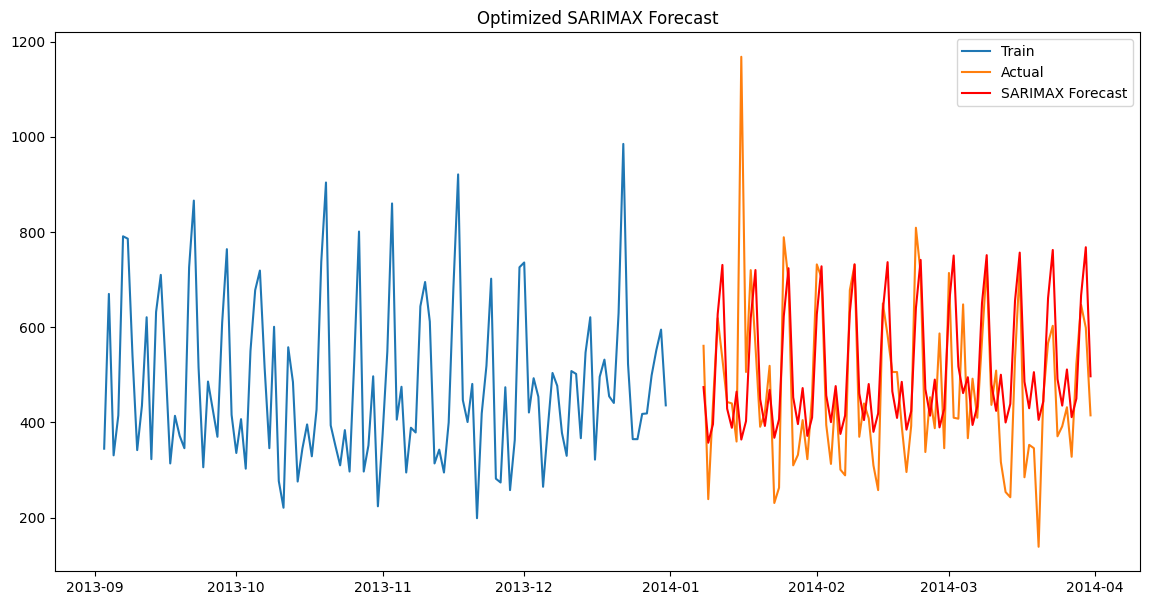

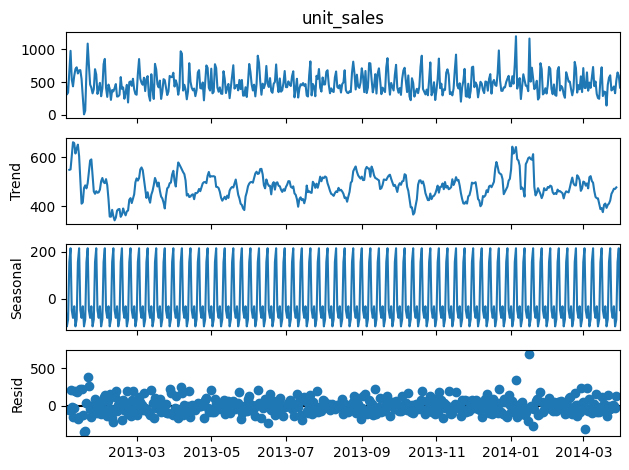

In [74]:

# 9. Plot Best Model (e.g., SARIMAX)
plt.figure(figsize=(14, 7))
plt.plot(train.index[-120:], train[target][-120:], label='Train')
plt.plot(test.index, test[target], label='Actual')
plt.plot(test.index, sarimax_forecast, label='SARIMAX Forecast', color='red')
plt.title('Optimized SARIMAX Forecast')
plt.legend()
plt.show()

# 10. Component Plot (for SARIMAX)
decomposition = seasonal_decompose(df[target], model='additive', period=7)
decomposition.plot()
plt.show()

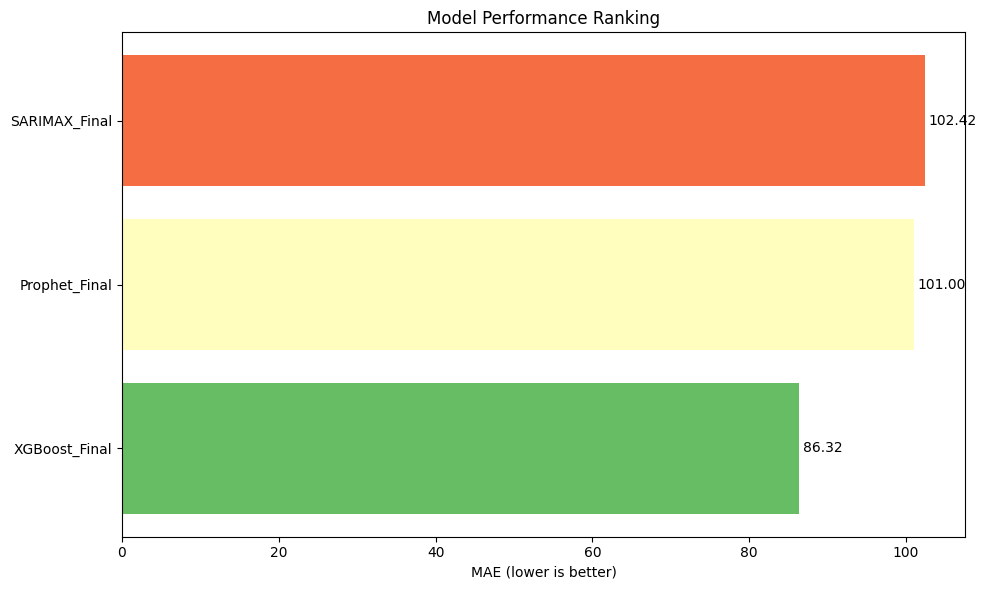

In [153]:
# Create a summary DataFrame
summary_data = []
for run in runs:
    run_name = run.data.tags.get('mlflow.runName', 'Unnamed')
    if 'mae' in run.data.metrics:
        summary_data.append({
            'Model': run_name,
            'MAE': run.data.metrics['mae'],
            'Run ID': run.info.run_id[:8]
        })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('MAE')

# Plot horizontal bar chart
plt.figure(figsize=(10, 6))
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(summary_df)))
plt.barh(summary_df['Model'], summary_df['MAE'], color=colors)
plt.xlabel('MAE (lower is better)')
plt.title('Model Performance Ranking')
for i, v in enumerate(summary_df['MAE']):
    plt.text(v + 0.5, i, f'{v:.2f}', va='center')
plt.tight_layout()
plt.show()

In [ ]:
mlflow ui --backend-store-uri file:///users/jmofl/pycharmProjects/mlrun